# Purpose

Compare the learnability of GO terms from composition-induced co-expression across manually curated tissue categories to their MGC Scores

In [38]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import gmean
import statsmodels.formula.api as smf

# Load MGC scores

In [39]:
def load_mgcs(path_to_json, mgcs_name:str)->pd.DataFrame:
	# Load the mgcs dictionary
	# Load the JSON file into a dictionary
	with open(path_to_json, 'r') as json_file:
		mgcs= json.load(json_file)
	# Convert the dictionary to a DataFrame
	mgcs = pd.DataFrame(list(mgcs.items()), columns=['gene', mgcs_name])
	return mgcs


brain_mgcs = pd.read_csv("../../MGC/data/mgc_gini_brain.csv", index_col=0)
brain_mgcs

,mgc_gini
GO:0000045,0.205555
GO:0000070,0.261048
GO:0000077,0.189123
GO:0000079,0.386707
GO:0000082,0.261464
...,...
GO:2001237,0.326138
GO:2001238,0.402848
GO:2001240,0.471196
GO:2001243,0.322552


# Load Bulk Learnability on the GO terms


In [40]:
def load_bulk(path:str) -> pd.DataFrame:
	df = pd.read_csv(path, index_col=0)
	return df
	
bulk = load_bulk("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/results/realbulk_reallabels/EGAD/melted_dfs/Brain_split.csv_melted_EGADs.csv.gz")
bulk.head()

,index,bootstrap,auc
0,GO:0000045,4,0.472959
1,GO:0000070,4,0.582309
2,GO:0000077,4,0.539752
3,GO:0000079,4,0.534392
4,GO:0000082,4,0.470443


# Merge Learnability with GO MGC scores

In [41]:
merged_bulk = pd.merge(bulk, brain_mgcs, left_on = 'index', right_index = True)

In [42]:
merged_bulk

,index,bootstrap,auc,mgc_gini
0,GO:0000045,4,0.472959,0.205555
0,GO:0000045,5,0.490810,0.205555
0,GO:0000045,36,0.537760,0.205555
0,GO:0000045,29,0.536433,0.205555
0,GO:0000045,23,0.556324,0.205555
...,...,...,...,...
1396,GO:2001244,32,0.619131,0.334780
1396,GO:2001244,48,0.618885,0.334780
1396,GO:2001244,35,0.687430,0.334780
1396,GO:2001244,46,0.659292,0.334780


# Look at the same relationship but using models trained on composition-corrected co-expression.

In [43]:
from statsmodels.formula.api import mixedlm, ols
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def model_bulk(bulk):
    powers = [1, 2]
    for p in powers:
        bulk[f'gini_pow_{p}'] = bulk['mgc_gini'] ** p

    power_terms = [f'gini_pow_{p}' for p in powers]
    formula = 'auc ~ ' + ' + '.join(power_terms)

    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error", category=ConvergenceWarning)
            model = mixedlm(formula=formula, data=bulk, groups=bulk['index']).fit()
    except (ConvergenceWarning, UserWarning):
        print("NOTE: Mixed LM failed to converge. Aggregating by GO term and fitting OLS.")
        bulk_agg = bulk.groupby('index')[['auc', 'mgc_gini'] + power_terms].mean().reset_index()
        model = ols(formula=formula, data=bulk_agg).fit()

    bulk['pred'] = model.predict(bulk)
    return model, bulk

bulk_model, merged_bulk = model_bulk(merged_bulk)
bulk_model.summary()

NOTE: Mixed LM failed to converge. Aggregating by GO term and fitting OLS.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    auc   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     169.5
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.30e-66
Time:                        14:09:53   Log-Likelihood:                 1799.5
No. Observations:                1396   AIC:                            -3593.
Df Residuals:                    1393   BIC:                            -3577.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6942      0.012     55.874      0.000       0.670       0.719
gini_pow_1    -0.7658      0.066    -11.664      0.000      -0.895      -0.637
gini_pow_2     1.1128      0.079     14.019      0.000       0.957       1.269
==============================================================================
Omnibus:                       45.965   Durbin-Watson:                   1.846
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.851
Skew:                           0.338   Prob(JB):                     2.25e-14
Kurtosis:                       3.790   Cond. No.                         63.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
ci = bulk_model.conf_int()
ci.columns = ['ci_lower', 'ci_upper']

coef_df = pd.DataFrame({
    'coef': bulk_model.params,
    'std_err': bulk_model.bse,
    'z_or_t': bulk_model.tvalues,
    'p_value': bulk_model.pvalues,
}).join(ci)

coef_df.to_csv("results/model_coefficients.csv")

with open("results/model_summary.txt", "w") as f:
    f.write(bulk_model.summary().as_text())

coef_df

,coef,std_err,z_or_t,p_value,ci_lower,ci_upper
Intercept,0.694193,0.012424,55.874047,0.000000e+00,0.669820,0.718565
gini_pow_1,-0.765840,0.065658,-11.664070,4.615940e-30,-0.894639,-0.637040
gini_pow_2,1.112834,0.079381,14.018932,7.241401e-42,0.957115,1.268553


### Plot

(1396, 4)


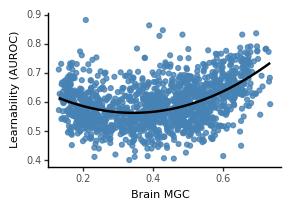

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/AUC_MGC_Brain_bulk.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 2 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/AUC_MGC_Brain_bulk.pdf


In [44]:
from plotnine import *
import pandas as pd

def plot_bulk(merged):

    # Aggregate data
    agg = (
        merged.groupby("index")[["auc", "mgc_gini", "pred"]]
        .mean()
        .reset_index()
    )

    print(agg.shape)

    p = (
        ggplot(agg, aes(x="mgc_gini"))
        +
        geom_point(aes(y="auc"), size=1.5, alpha=0.8, color="steelblue")
        +
        geom_line(aes(y="pred"), color="black", size=1)
        +
        labs(
            x="Brain MGC",
            y="Learnability (AUROC)"
        )
        +
        theme_classic()
        +
        theme(
            text=element_text(size=8),
            axis_text_x=element_text(size=7),
            axis_text_y=element_text(size=7),
            figure_size=(3, 2)
        )
    )

    print(p)

    p.save("results/AUC_MGC_Brain_bulk.png", dpi=300)
    p.save("results/AUC_MGC_Brain_bulk.pdf", dpi=300)


# Call function
plot_bulk(merged_bulk)